In [ ]:
import os
import qrcode
import cv2
from tkinter import filedialog
from tkinter import *
from pyzbar.pyzbar import decode
from PIL import Image
from IPython import display

root = Tk()

def make_qrcode(data, save_path='./qrcode.png', border=5, image_size=(300, 300), icon_path='', factor=3.5):
    # Generar cuerpo de código QR
    qr = qrcode.QRCode(error_correction=qrcode.constants.ERROR_CORRECT_H, border=border)
    qr.add_data(data)  # Escribir datos en código QR
    qr.make()
    qrcode_image = qr.make_image().resize(image_size, Image.ANTIALIAS).convert('RGBA')

    if icon_path:  # Pega un ícono en medio del código QR
        icon_size = int(image_size[0] / factor), int(image_size[1] / factor)
        icon = Image.open(icon_path).resize(icon_size, Image.ANTIALIAS).convert('RGBA')
        icon_margin = int((image_size[0] - icon_size[0]) / 2), int((image_size[1] - icon_size[1]) / 2)
        mask = Image.new('RGBA', icon_size, color='white')
        qrcode_image.paste(mask, icon_margin, mask)
        qrcode_image.paste(icon, icon_margin, icon)

    # Guarde el código QR como un archivo
    if not os.path.isdir(os.path.dirname(save_path)):
        os.makedirs(os.path.dirname(save_path))
    qrcode_image.save(save_path)

    
    
def pedirQrCamara():
    cap = cv2.VideoCapture(0)
    cap.set(3, 640)
    cap.set(4, 480)
    a=""
    while True:
        succes, img = cap.read()

        for barcode in decode(img):
            myData = barcode.data.decode('utf-8')
            a=myData
        cv2.imshow('Tomando imagen Qr', img)
        cv2.waitKey(1)
        if a:
            break

    cap.release()
    cv2.destroyAllWindows()
    print(a)
    return a


def pedirQrGuardado():
    fotoPersona =  filedialog.askopenfilename()
    img = cv2.imread(fotoPersona)
    a=""
    for barcode in decode(img):
        myData = barcode.data.decode('utf-8')

        if myData:
            a=myData
            break
    return a

def pedirFoto():
    print("Seleccione una foto para agregar a su qr")
    root.filename =  filedialog.askopenfilename(initialdir = "/",title = "Seleccione una foto para agregar a su qr",filetypes = (("jpeg files","*.jpg"),("all files","*.*")))
    fotoPersona=root.filename
    return fotoPersona

def obtenerInfodelQr(qrImage):
    detector = cv2.QRCodeDetector()
    qr_Detectar = cv2.imread(qrImage)
    text, matrix, val = detector.detectAndDecode(qr_Detectar) ##Se decodifica lo del qr y lo representa por orden almacena las variables
    return text

def opcionQR(a=0):
    elegido=""
    if(a==1):
        elegido=pedirQrGuardado()
    elif(a==2):
        elegido=pedirQrCamara()
    return elegido


if __name__ == '__main__':
    qr=opcionQR(1)
    foto=pedirFoto()
    
    if(qr != ""):
        make_qrcode(data=qr, save_path='./QRCovid.png', icon_path=foto)
    else:
        print("Porfavor escoja un qr válido")

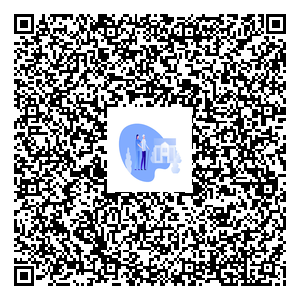

In [2]:
display.Image("QRCovid.png")